In [11]:
from IPython.display import HTML, display

display(HTML("<style>.container { width:100% !important; }</style>"))

In [12]:
import sys

print(sys.executable)
!{sys.executable} -m ensurepip --upgrade


/opt/venv/bin/python


Looking in links: /tmp/tmp2odjj71k


In [13]:
import sys

!{sys.executable} -m pip install umap-learn



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [14]:
import json
import os

import matplotlib as mpl
import numpy as np
import tqdm
import umap
from matplotlib import pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from PIL import Image
from sklearn.manifold import TSNE

In [ ]:
from PIL import ImageOps, UnidentifiedImageError


def load_png_directory(directory, target_size=(192, 192), sample_size=1200, seed=42):
    png_files = sorted(
        f
        for f in os.listdir(directory)
        if f.lower().endswith(".png") and not f.startswith(("._", "."))
    )
    if len(png_files) == 0:
        raise ValueError("No se encontraron PNG válidos")

    if sample_size is not None and sample_size < len(png_files):
        rng = np.random.default_rng(seed)
        idx = np.sort(rng.choice(len(png_files), size=sample_size, replace=False))
        png_files = [png_files[i] for i in idx]

    w, h = target_size
    images = np.empty((len(png_files), h, w, 3), dtype=np.uint8)
    valid_png_files = []

    write_i = 0
    for file in tqdm.tqdm(png_files):
        path = os.path.join(directory, file)
        try:
            with Image.open(path) as im:
                im = im.convert("RGB")
                im = ImageOps.contain(im, target_size, method=Image.Resampling.BICUBIC)

                canvas = Image.new("RGB", target_size, (255, 255, 255))
                x = (w - im.width) // 2
                y = (h - im.height) // 2
                canvas.paste(im, (x, y))

            images[write_i] = np.asarray(canvas, dtype=np.uint8)
            valid_png_files.append(file)
            write_i += 1
        except UnidentifiedImageError:
            print(f"Saltando archivo no válido: {file}")

    images = images[:write_i]
    return images, valid_png_files

In [9]:
!find /workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures -name '._*' -delete
!find /workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures -name '.DS_Store' -delete

In [ ]:
images, png_files = load_png_directory(
    "/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures",
    target_size=(192, 192),
    sample_size=1200,
    seed=42,
)

  0%|          | 0/1200 [00:00<?, ?it/s]

100%|██████████| 1200/1200 [00:08<00:00, 141.87it/s]


In [18]:
ds = json.load(
    open(
        "/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/dataset_merged_labeled.json"
    )
)
labels = set([lbl for v in ds.values() for lbl in v])
labels = {lbl: [fn for fn, lbls in ds.items() if lbl in lbls] for lbl in labels}

In [19]:
labels.keys()

dict_keys(['helmet', 'facial hair', 'glasses', 'hat', 'robot', 'happy', 'alien', 'human', 'cape', 'angry'])

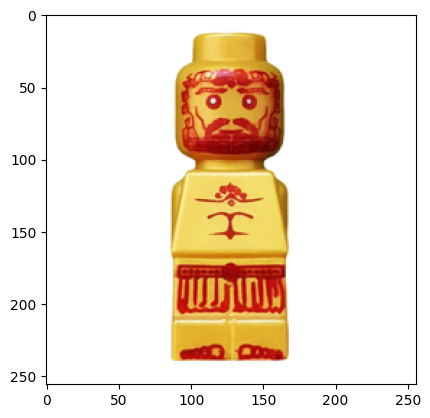

In [20]:
%matplotlib inline
plt.imshow(images[0])
plt.show()

In [ ]:
# def embed(images, labels=None):
#    num_images, height, width, channels = images.shape
#    image_data = images.reshape((num_images, height * width * channels))
#    embedding = umap.UMAP(verbose=True).fit_transform(image_data, y=labels)
#    return embedding

from sklearn.decomposition import PCA


def embed(images, labels=None, pca_components=128):
    n, h, w, c = images.shape
    x = images.reshape(n, -1).astype(np.float32) / 255.0
    x /= np.float32(255.0)

    if pca_components is not None:
        x = PCA(
            n_components=pca_components, svd_solver="randomized", random_state=42
        ).fit_transform(x)

    return umap.UMAP(verbose=True, random_state=42).fit_transform(x, y=labels)

In [22]:
def img_trans(image):
    img = Image.fromarray(image).convert("RGBA")
    width, height = img.size
    pixdata = img.load()
    for y in range(height):
        for x in range(width):
            if pixdata[x, y] == (255, 255, 255, 255):
                pixdata[x, y] = (255, 255, 255, 0)
    return img

In [23]:
y = []
for file in png_files:
    for i, lbl in enumerate(["human", "robot", "alien"]):
        if file.replace(".png", "") in labels[lbl]:
            y.append(i)
            break
    else:
        y.append(-1)

In [24]:
np.unique(y, return_counts=True)

(array([-1,  0,  1,  2]), array([1127,   49,    9,   15]))

In [25]:
%matplotlib notebook

In [26]:
embedding = embed(images)

: 

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15))

plt.xlim(np.min(embedding[:, 0]), np.max(embedding[:, 0]))
plt.ylim(np.min(embedding[:, 1]), np.max(embedding[:, 1]))

for i, t in enumerate(embedding):
    ab = AnnotationBbox(
        OffsetImage(img_trans(images[i]), zoom=0.1),
        (t[0], t[1]),
        bboxprops={
            "color": mpl.colormaps["Pastel1"](y[i]) if y[i] > -1 else "#ffffff00",
            "fill": True,
        },
    )
    ax.add_artist(ab)

plt.show()

In [ ]:
embedding = embed(images, y)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15))

plt.xlim(np.min(embedding[:, 0]), np.max(embedding[:, 0]))
plt.ylim(np.min(embedding[:, 1]), np.max(embedding[:, 1]))

for i, t in enumerate(embedding):
    ab = AnnotationBbox(
        OffsetImage(img_trans(images[i]), zoom=0.1),
        (t[0], t[1]),
        bboxprops={
            "color": mpl.colormaps["Pastel1"](y[i]) if y[i] > -1 else "#ffffff00",
            "fill": True,
        },
    )
    ax.add_artist(ab)

plt.show()